In [6]:
import os
import json
import matplotlib.pyplot as plt

import xarray as xr
import seaborn as sns
import pandas as pd
import numpy as np

import scipy as sp

In [7]:
from pypalettes import load_cmap
cmap = load_cmap("highcontrast")

In [8]:
# Reanalysis data
obs = pd.read_csv('/home/links/ct715/eddy_feedback/chapter1/reanalysis/data/jra55_efp_results.csv')
obs = obs[obs['div1_method'] != 'div1_pr'] 
obs = obs[obs['period'] == '1979-2016'].reset_index(drop=True)

efp_6h_nh_500 = obs[obs['time_freq'] == '6h']['efp_nh_500'].values[0]
efp_6h_sh_500 = obs[obs['time_freq'] == '6h']['efp_sh_500'].values[0]
efp_daily_nh_500 = obs[obs['time_freq'] == 'daily']['efp_nh_500'].values[0]
efp_daily_sh_500 = obs[obs['time_freq'] == 'daily']['efp_sh_500'].values[0]

In [9]:
path = '/home/links/ct715/eddy_feedback/chapter1/cmip6/data/100y/cmip6_daily_efp_winters_100y.csv'

# path = '/home/users/cturrell/documents/eddy_feedback/chapter1/cmip6/data/100y/cmip6_6h_efp_winters_100y.csv'

df = pd.read_csv(path)
df = df[['model', 'efp_nh', 'efp_sh']]
df

,model,efp_nh,efp_sh
0,AWI-ESM-1-1-LR,0.1758,0.2034
1,CMCC-CM2-SR5,0.2909,0.1241
2,CMCC-ESM2,0.2358,0.2104
3,CanESM5-1,0.2806,0.2757
4,EC-Earth3,0.1948,0.1708
5,EC-Earth3-CC,0.2057,0.1348
6,EC-Earth3-LR,0.2140,0.1232
7,EC-Earth3-Veg,0.1781,0.1341
8,EC-Earth3-Veg-LR,0.2415,0.1976
9,IPSL-CM5A2-INCA,0.2228,0.2844


In [10]:
path2 = '/home/links/ct715/eddy_feedback/chapter1/cmip6/data/100y/cmip6_6h_efp_winters_100y.csv'

df2 = pd.read_csv(path2)
df2 = df2[['model', 'efp_nh', 'efp_sh']]
df2

,model,efp_nh,efp_sh
0,AWI-ESM-1-1-LR,0.247332,0.359282
1,CMCC-CM2-SR5,0.362686,0.293373
2,CMCC-ESM2,0.322007,0.376035
3,CanESM5-1,0.361045,0.424154
4,EC-Earth3,0.261561,0.276905
5,EC-Earth3-CC,0.240222,0.238292
6,EC-Earth3-LR,0.278776,0.250698
7,EC-Earth3-Veg,0.259928,0.262604
8,EC-Earth3-Veg-LR,0.314512,0.319528
9,IPSL-CM5A2-INCA,0.324401,0.401678


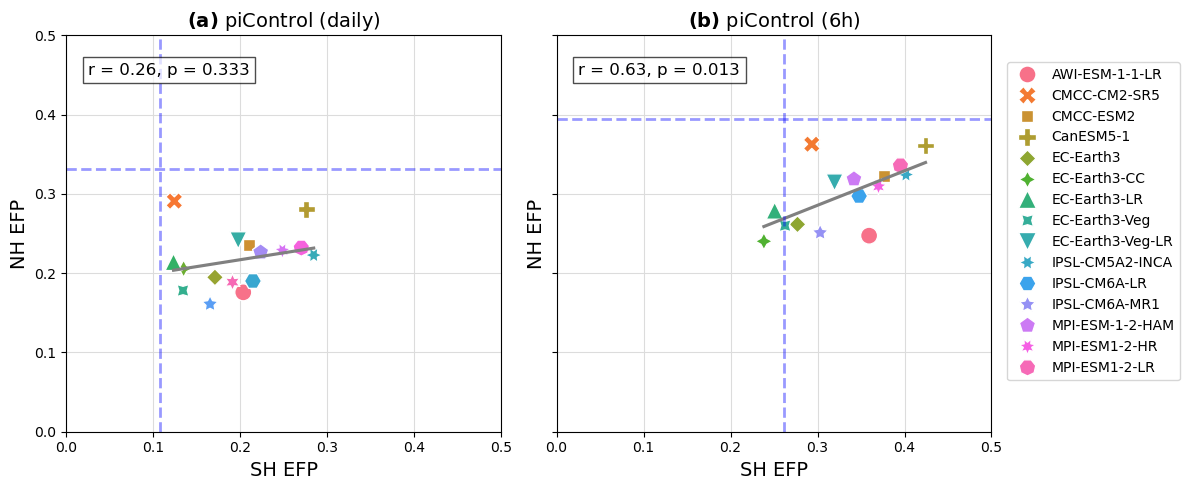

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Panel (a)
sns.regplot(ax=axes[0], data=df, x='efp_sh', y='efp_nh',
            scatter_kws={'color': 'white'}, line_kws={"color": "gray"}, ci=None)
sns.scatterplot(ax=axes[0], data=df, x='efp_sh', y='efp_nh',
                hue='model', style='model', s=150)
corr_set = df[df['model'] != 'JRA55 (1979-2016)']
r, p = sp.stats.pearsonr(x=corr_set['efp_nh'], y=corr_set['efp_sh'])
axes[0].text(0.05, 0.9, f"r = {r:.2f}, p = {p:.3f}", transform=axes[0].transAxes,
             bbox=dict(facecolor="white", alpha=0.7), fontsize=12)
axes[0].set_xlabel('SH EFP', fontsize=14)
axes[0].set_ylabel('NH EFP', fontsize=14)
axes[0].set_xlim(0, 0.5)
axes[0].set_ylim(0, 0.5)
axes[0].set_title('$\\bf{(a)}$ piControl (daily)', fontsize=14)
axes[0].legend_.remove()
axes[0].grid(visible=True, color='gainsboro')
axes[0].set_axisbelow(True)

# Add observational lines for daily data
axes[0].axhline(efp_daily_nh_500, color='blue', linestyle='--', linewidth=2, alpha=0.4)
axes[0].axvline(efp_daily_sh_500, color='blue', linestyle='--', linewidth=2, alpha=0.4)

# Panel (b)
sns.regplot(ax=axes[1], data=df2, x='efp_sh', y='efp_nh',
            scatter_kws={'color': 'white'}, line_kws={"color": "gray"}, ci=None)
sns.scatterplot(ax=axes[1], data=df2, x='efp_sh', y='efp_nh',
                hue='model', style='model', s=150)
corr_set = df2[df2['model'] != 'JRA55 (1979-2016)']
r, p = sp.stats.pearsonr(x=corr_set['efp_nh'], y=corr_set['efp_sh'])
axes[1].text(0.05, 0.9, f"r = {r:.2f}, p = {p:.3f}", transform=axes[1].transAxes,
             bbox=dict(facecolor="white", alpha=0.7), fontsize=12)
axes[1].set_xlabel('SH EFP', fontsize=14)
axes[1].set_ylabel('NH EFP', fontsize=14)
axes[1].set_xlim(0, 0.5)
axes[1].set_ylim(0, 0.5)
axes[1].set_title('$\\bf{(b)}$ piControl (6h)', fontsize=14)
axes[1].legend_.remove()
axes[1].grid(visible=True, color='gainsboro')
axes[1].set_axisbelow(True)

# Add observational lines for 6h data
axes[1].axhline(efp_6h_nh_500, color='blue', linestyle='--', linewidth=2, alpha=0.4)
axes[1].axvline(efp_6h_sh_500, color='blue', linestyle='--', linewidth=2, alpha=0.4)

# Move legend outside the left panel now
axes[1].legend(bbox_to_anchor=(1.02, 0.95), loc='upper left')
plt.tight_layout()
# save_path = '/home/links/ct715/eddy_feedback/chapter1/zz_paper_plots'
# plt.savefig(os.path.join(save_path, 'sub-daily_vs_daily.png'), bbox_inches='tight')
plt.show()

# Multiple wavenumber comparison